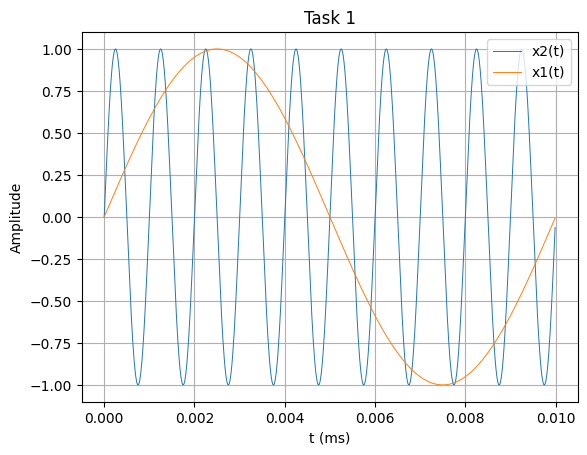

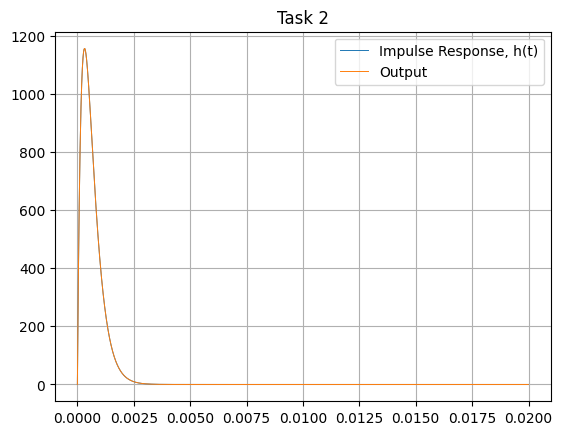

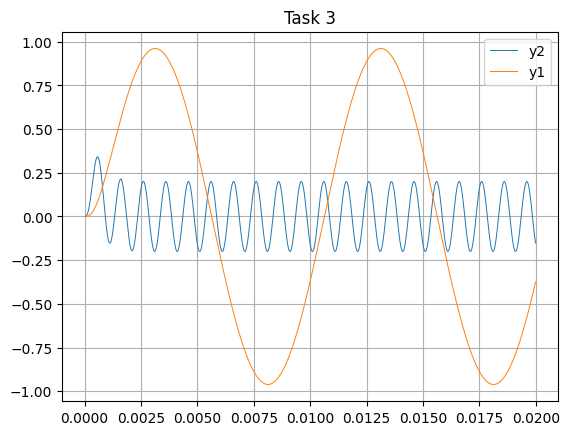

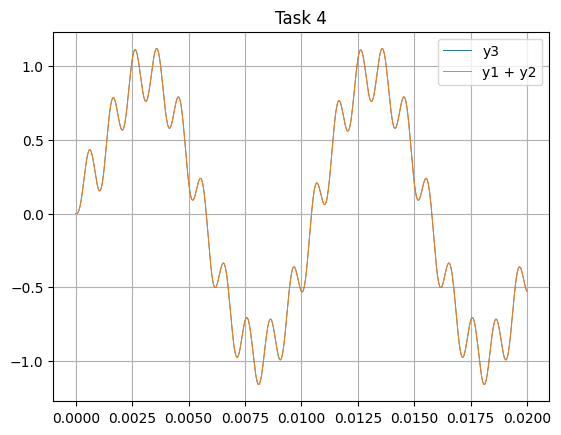

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sounddevice as sd

# -------------- TASK 1 -------------- #

T1 = 0.01 #s
f2 = 1000 #Hz
start = 0
stop = 5
increment = 0.00001
t = np.arange(start, stop, increment)
A = 1
phi = 0
omega_1 = 2*np.pi*f2
omega_2 = (2*np.pi) / T1

x_1 = A*np.sin(omega_1*t + phi)
x_2 = A*np.sin(omega_2*t + phi)

fig, ax = plt.subplots()
plt.title("Task 1")
ax.plot(t[:1000], x_1[:1000], linewidth=0.7, label="x2(t)")
ax.plot(t[:1000], x_2[:1000], linewidth=0.7, label="x1(t)")
ax.grid()
xmin, xmax, ymin, ymax = ax.axis()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("t (ms)")
ax.set_ylabel("Amplitude")
plt.legend()

#sd.play(x_1, 1/increment, blocking=True)
#sd.play(x_2, 1/increment, blocking=True)

# -------------- TASK 2 -------------- #

dt = 0.00001
alpha = 1000*np.pi
start = 0
stop = 0.02
t2 = np.arange(start, stop, dt)
h_t = (alpha**2)*t2*np.exp(-alpha*t2) # Impulse response

# Dirac delta function
d = np.zeros(t2.shape)
d[0] = 1/dt

y_out = dt*signal.convolve(d, h_t, method='direct')
y_out = y_out[:d.shape[0]]

fig, ax = plt.subplots()
plt.title("Task 2")
ax.plot(t2, h_t, linewidth=0.7, label="Impulse Response, h(t)")
ax.plot(t2, y_out, linewidth=0.7, label="Output")
xmin, xmax, ymin, ymax = ax.axis()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.grid()
plt.legend()

# -------------- TASK 3 -------------- #

y_out1 = dt*signal.convolve(x_1, h_t, method='direct')
y_out2 = dt*signal.convolve(x_2, h_t, method='direct')

y_out1 = y_out1[:d.shape[0]]
y_out2 = y_out2[:d.shape[0]]


fig, ax = plt.subplots()
plt.title("Task 3")
ax.plot(t2, y_out1, linewidth=0.7, label="y2")
ax.plot(t2, y_out2, linewidth=0.7, label="y1")
#ax.plot(t2, h_t, linewidth=0.7, label="Impulse Response, h(t)")
xmin, xmax, ymin, ymax = ax.axis()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.grid()
plt.legend()

# -------------- TASK 4 -------------- #

x_3 = x_1 + x_2 
y_out3 = dt*signal.convolve(x_3, h_t, method='direct')
y_out3 = y_out3[:d.shape[0]]
y_tot = y_out1 + y_out2

fig, ax = plt.subplots()
plt.title("Task 4")
ax.plot(t2, y_out3, linewidth=0.7, label="y3")
ax.plot(t2, y_tot, linewidth=0.7, label="y1 + y2")
xmin, xmax, ymin, ymax = ax.axis()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.grid()
plt.legend()
plt.show()